<a href="https://colab.research.google.com/github/rafidhadizuhair/rafidhadizuhair.github.io/blob/main/Pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

# Load dataset (contoh: Iris)
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Buat model Decision Tree
dt = DecisionTreeClassifier(
    criterion='gini',      # 'gini' atau 'entropy'
    max_depth=3,           # batasi kedalaman untuk hindari overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Training
dt.fit(X_train, y_train)

# Prediksi
y_pred = dt.predict(X_test)

# Evaluasi
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Akurasi: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



Akurasi: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



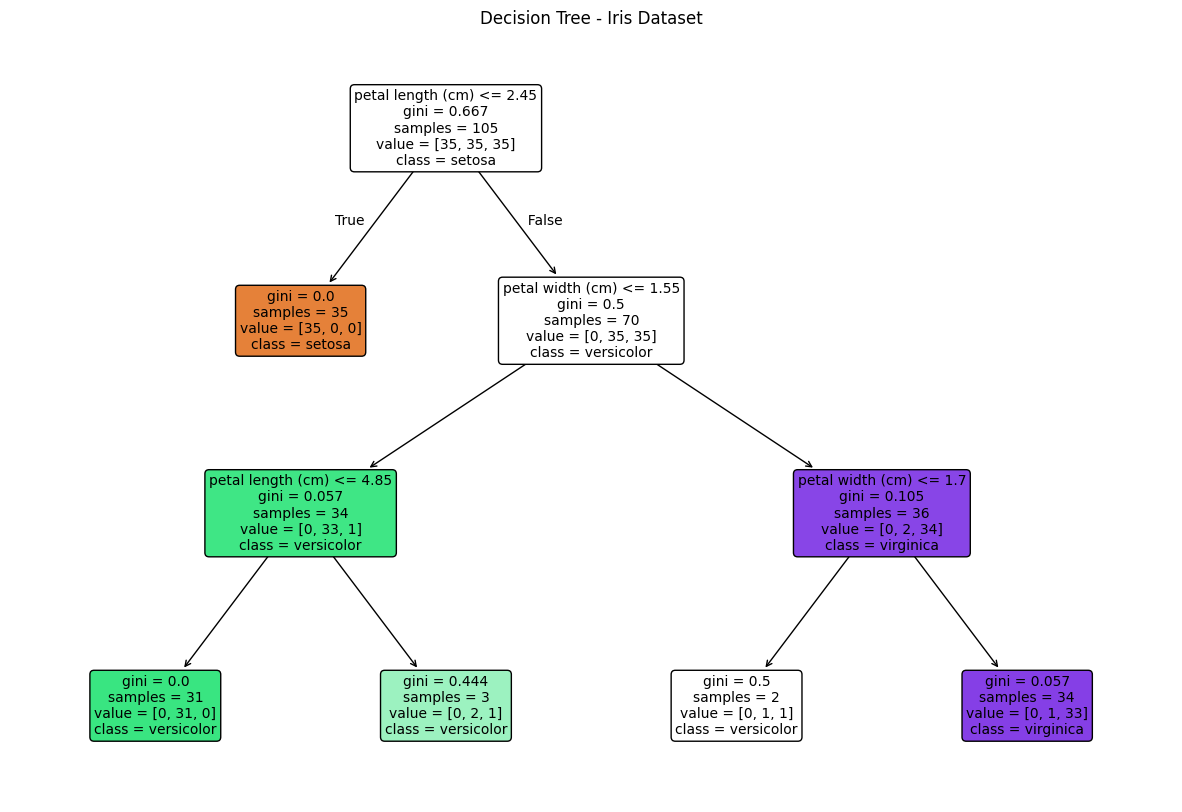


Feature Importance:
             feature  importance
2  petal length (cm)    0.541766
3   petal width (cm)    0.458234
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris

# ======================
# Load Dataset
# ======================
iris = load_iris()
X = iris.data
y = iris.target

# ======================
# Split Data
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ======================
# Model Decision Tree
# ======================
dt = DecisionTreeClassifier(
    criterion='gini',      # bisa juga 'entropy'
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# ======================
# Training
# ======================
dt.fit(X_train, y_train)

# ======================
# Prediksi
# ======================
y_pred = dt.predict(X_test)

# ======================
# Evaluasi
# ======================
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# ======================
# Visualisasi Decision Tree
# ======================
plt.figure(figsize=(15, 10))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Iris Dataset")
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================
# Feature Importance
# ======================
importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance)

In [ ]:
import pandas as pd
import numpy as np

class SimpleRuleBasedClassifier:
    def __init__(self):
        self.rules = []
        self.default_class = None

    def add_rule(self, conditions, class_label, confidence=None):
        """
        Tambah aturan IF-THEN
        conditions: dict {feature: value}
        """
        self.rules.append({
            'conditions': conditions,
            'class': class_label,
            'confidence': confidence or 1.0
        })

        # Urutkan berdasarkan confidence (descending)
        self.rules.sort(key=lambda x: x['confidence'], reverse=True)

    def predict_one(self, x):
        """Prediksi satu data point"""
        for rule in self.rules:
            match = True
            for feature, value in rule['conditions'].items():
                if x[feature] != value:
                    match = False
                    break
            if match:
                return rule['class']
        return self.default_class

    def predict(self, X):
        return [self.predict_one(x) for x in X]

    def set_default(self, class_label):
        self.default_class = class_label


# ======================
# Contoh penggunaan
# ======================

# Dataset sederhana: Outlook, Temperature, Play
data = [
    {'Outlook': 'Sunny', 'Temp': 'Hot', 'Play': 'No'},
    {'Outlook': 'Sunny', 'Temp': 'Mild', 'Play': 'No'},
    {'Outlook': 'Overcast', 'Temp': 'Hot', 'Play': 'Yes'},
    {'Outlook': 'Rainy', 'Temp': 'Mild', 'Play': 'Yes'},
    {'Outlook': 'Rainy', 'Temp': 'Cool', 'Play': 'Yes'}
]

# Buat classifier
clf = SimpleRuleBasedClassifier()

# Tambah aturan
clf.add_rule({'Outlook': 'Overcast'}, 'Yes')
clf.add_rule({'Outlook': 'Sunny', 'Temp': 'Hot'}, 'No', confidence=0.8)
clf.add_rule({'Outlook': 'Rainy'}, 'Yes', confidence=0.7)

# Default class
clf.set_default('Yes')

# Testing
test_data = {'Outlook': 'Sunny', 'Temp': 'Hot'}
print(f"Prediksi: {clf.predict_one(test_data)}")
# Output: No

Prediksi: No


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
import numpy as np

def extract_rules(tree, feature_names, class_names, node_id=0, current_rule=None):
    # Ekstrak aturan IF-THEN dari decision tree
    if current_rule is None:
        current_rule = []

    rules = []

    # Cek apakah node daun (leaf)
    if tree.children_left[node_id] == tree.children_right[node_id]:
        # Node daun: output kelas
        class_id = np.argmax(tree.value[node_id][0])
        rule_str = "IF " + " AND ".join(current_rule) + f" THEN {class_names[class_id]}"
        rules.append(rule_str)
    else:
        # Node internal: rekursif ke kiri dan kanan
        feature = feature_names[tree.feature[node_id]]
        threshold = tree.threshold[node_id]

        # Cabang kiri (<= threshold)
        left_rule = current_rule + [f"{feature} <= {threshold:.2f}"]
        rules.extend(extract_rules(tree, feature_names, class_names, tree.children_left[node_id], left_rule))

        # Cabang kanan (> threshold)
        right_rule = current_rule + [f"{feature} > {threshold:.2f}"]
        rules.extend(extract_rules(tree, feature_names, class_names, tree.children_right[node_id], right_rule))

    return rules

# Contoh ekstraksi dari model sebelumnya
iris = load_iris()
dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(iris.data, iris.target)

rules = extract_rules(dt.tree_, iris.feature_names, iris.target_names)

print("Aturan yang diekstrak:")
for i, rule in enumerate(rules):
    print(f"{i+1}. {rule}")

Aturan yang diekstrak:
1. IF petal length (cm) <= 2.45 THEN setosa
2. IF petal length (cm) > 2.45 AND petal width (cm) <= 1.75 THEN versicolor
3. IF petal length (cm) > 2.45 AND petal width (cm) > 1.75 THEN virginica
